# 05 - Deep Learning Model
---
**Objective:** Train deep learning model, and compare with xgboost

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import torch
from sklearn.preprocessing import StandardScaler

# Add project root to path
import os
import sys
sys.path.append(os.path.abspath('../'))
from src.data.loader import load_csv
from src.models.trainer import split_data, encoding, class_weights, clean_feature_names
from src.models.deeplearning import make_loader, FraudMLP, train_mlp,  find_optimal_threshold, evaluate

# Settings
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

print("Libraries imported successfully!")
print(f"Python version: {sys.version.split()[0]}")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Libraries imported successfully!
Python version: 3.13.5
Pandas version: 2.3.1
NumPy version: 2.3.2


In [2]:
# Load data
train = load_csv('../data/external/train_top_features.csv')
print()
test = load_csv('../data/external/test_top_features.csv')

👉 Loading: ../data/external/train_top_features.csv
DATASET INFORMATION
Shape: 1,296,675 rows × 10 columns
Memory usage: 150.87 MB

Column types:
int64      6
float64    3
object     1
Name: count, dtype: int64

Missing values: 0

👉 Loading: ../data/external/test_top_features.csv
DATASET INFORMATION
Shape: 555,719 rows × 10 columns
Memory usage: 64.66 MB

Column types:
int64      6
float64    3
object     1
Name: count, dtype: int64

Missing values: 0


In [3]:
X_train, y_train = split_data(train)
X_test,  y_test  = split_data(test)

X_train = clean_feature_names(X_train)
X_test  = clean_feature_names(X_test)

X_train, X_test = encoding(X_train, X_test)
scale_pos_weight = class_weights(y_train)

Feature shape: (1296675, 9)
scale_pos_weight: 171.75


In [4]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# Scale features
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_train)
X_te_s  = scaler.transform(X_test)

train_loader = make_loader(X_tr_s, y_train, shuffle=True)
test_loader  = make_loader(X_te_s,  y_test,  shuffle=False)

In [5]:
# Train MLP
mlp = FraudMLP(in_dim=9, hidden_dims=(256, 128, 64), dropout=0.3)

mlp, history = train_mlp(
    DEVICE, mlp, train_loader, y_train, test_loader, y_test,
    pos_weight_val=scale_pos_weight, epochs=30, lr=1e-3, patience=5
)

Epoch 001 | loss=0.64188 | PR-AUC=0.25432 | Brier=0.05201
Epoch 002 | loss=0.46702 | PR-AUC=0.57382 | Brier=0.03390
Epoch 003 | loss=0.40092 | PR-AUC=0.60778 | Brier=0.03905
Epoch 004 | loss=0.36107 | PR-AUC=0.72304 | Brier=0.03040
Epoch 005 | loss=0.33922 | PR-AUC=0.74405 | Brier=0.03911
Epoch 006 | loss=0.32153 | PR-AUC=0.74340 | Brier=0.03701
Epoch 007 | loss=0.31211 | PR-AUC=0.75899 | Brier=0.02945
Epoch 008 | loss=0.30083 | PR-AUC=0.77428 | Brier=0.03239
Epoch 009 | loss=0.29227 | PR-AUC=0.78145 | Brier=0.02808
Epoch 010 | loss=0.28240 | PR-AUC=0.78742 | Brier=0.03000
Epoch 011 | loss=0.27143 | PR-AUC=0.79392 | Brier=0.03486
Epoch 012 | loss=0.26328 | PR-AUC=0.77285 | Brier=0.02838
Epoch 013 | loss=0.25981 | PR-AUC=0.79630 | Brier=0.03012
Epoch 014 | loss=0.25854 | PR-AUC=0.78088 | Brier=0.02976
Epoch 015 | loss=0.24888 | PR-AUC=0.80916 | Brier=0.02700
Epoch 016 | loss=0.24185 | PR-AUC=0.80790 | Brier=0.03267
Epoch 017 | loss=0.24546 | PR-AUC=0.81759 | Brier=0.03212
Epoch 018 | lo

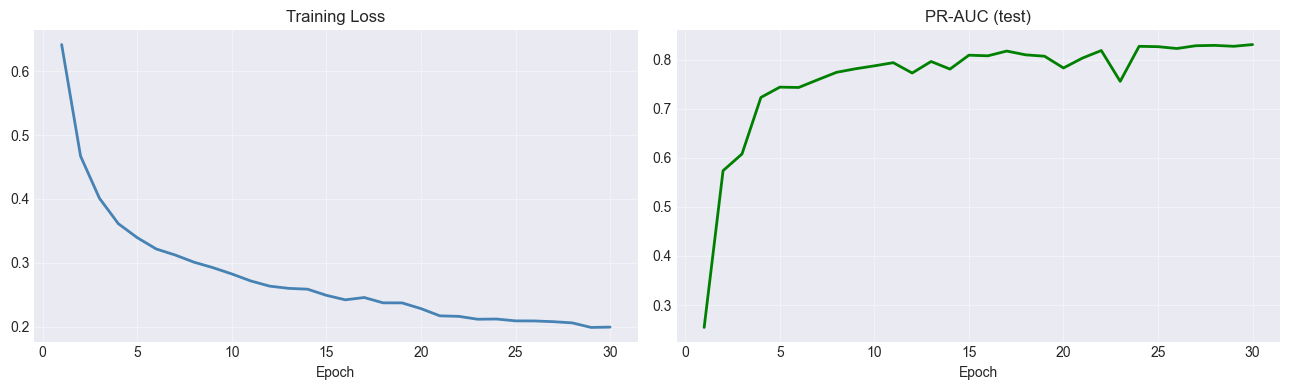

In [6]:
# Training curve
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history['epoch'], history['loss'], color='steelblue', lw=2)
axes[0].set_title('Training Loss'); axes[0].set_xlabel('Epoch')
axes[0].grid(True, alpha=0.4)

axes[1].plot(history['epoch'], history['pr_auc'], color='green', lw=2)
axes[1].set_title('PR-AUC (test)'); axes[1].set_xlabel('Epoch')
axes[1].grid(True, alpha=0.4)

plt.tight_layout(); plt.show()

In [7]:
# Evaluate MLP
mlp.eval()
all_probs = []
with torch.no_grad():
    for X_batch, _ in test_loader:
        logits = mlp(X_batch.to(DEVICE))
        all_probs.extend(torch.sigmoid(logits).cpu().numpy())

y_prob_mlp = np.array(all_probs)
thr_mlp    = find_optimal_threshold(y_test, y_prob_mlp)
evaluate('MLP', y_test, y_prob_mlp, thr_mlp)


-- MLP (thr=0.9659) --
  PR-AUC    : 0.83085
  Brier     : 0.02949
  Precision : 0.6629
  Recall    : 0.8121
  F2        : 0.7771
  Confusion Matrix:
[[552688    886]
 [   403   1742]]
